ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

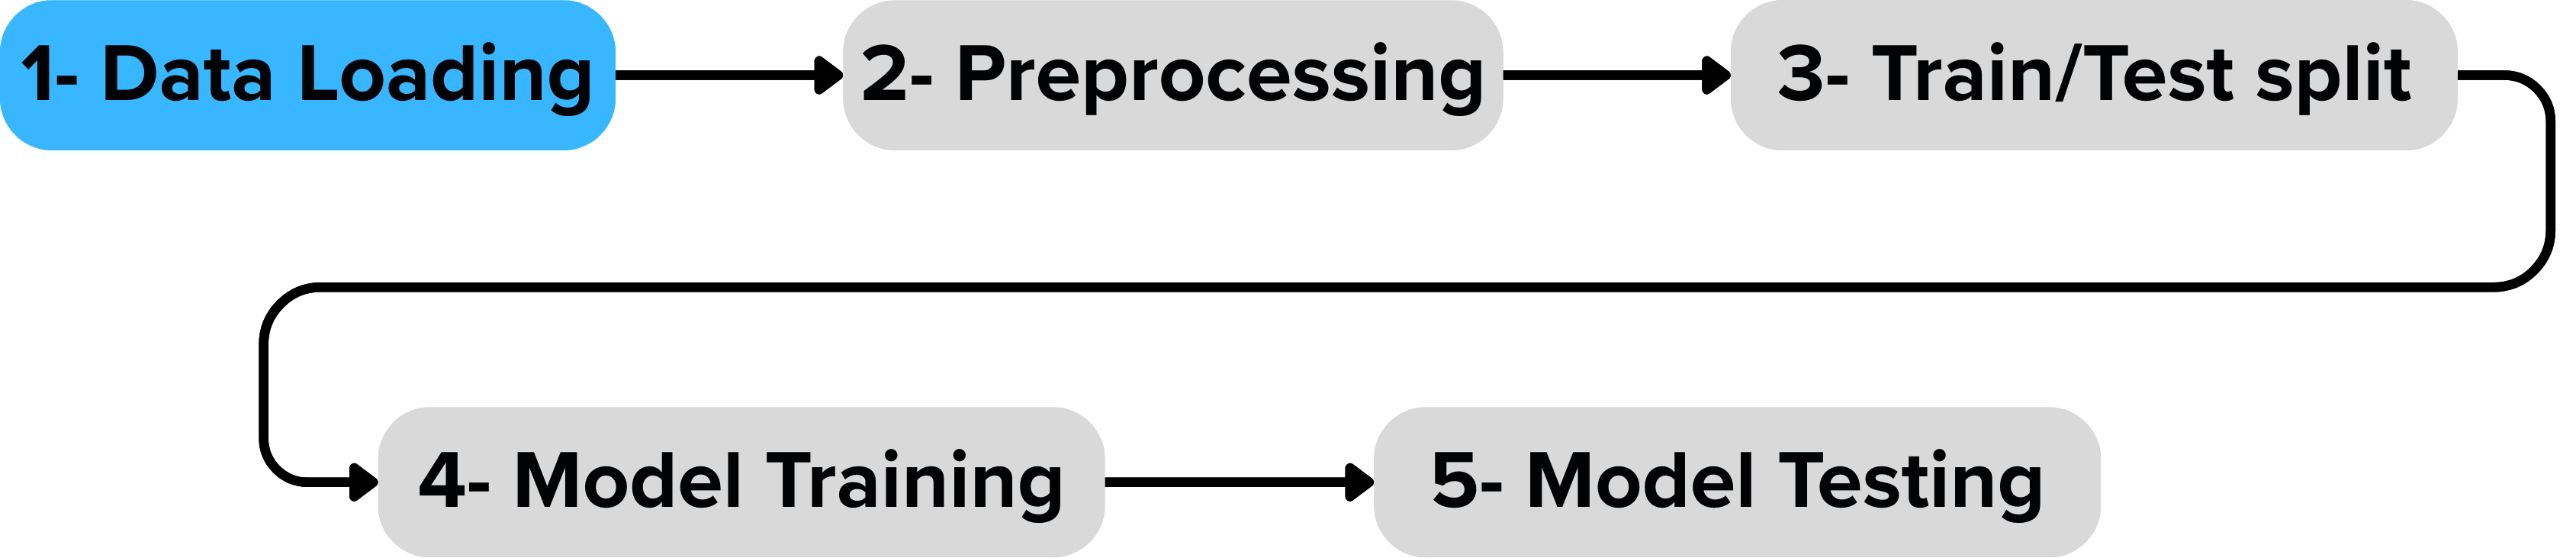

In [ ]:
%pip install matplotlib seaborn

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [2]:
# Load Dataset

df = pd.read_csv("Dataset.csv")

# Display first 5 rows
df.head()

,Date,Close,High,Low,Open,Volume
0,2016-01-04,0.789588,0.794710,0.781538,0.787636,358076000
1,2016-01-05,0.802272,0.815688,0.792759,0.804467,490272000
2,2016-01-06,0.769098,0.792759,0.760073,0.789100,449344000
3,2016-01-07,0.738607,0.754950,0.728850,0.749828,645304000
4,2016-01-08,0.722752,0.748852,0.721289,0.748120,398472000


### Check Missing Values

In [3]:
# Check all values
print(df.isna())

       Date  Close   High    Low   Open  Volume
0     False  False  False  False  False   False
1     False  False  False  False  False   False
2     False  False  False  False  False   False
3     False  False  False  False  False   False
4     False  False  False  False  False   False
...     ...    ...    ...    ...    ...     ...
2509  False  False  False  False  False   False
2510  False  False  False  False  False   False
2511  False  False  False  False  False   False
2512  False  False  False  False  False   False
2513  False  False  False  False  False   False

[2514 rows x 6 columns]


In [4]:
print(df.isna().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


### Check duplicate rows

In [5]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [6]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (2514, 6) 

number of rows:  2514
number of columns:  6


### Data type of columns

In [7]:
# viewing the data types of columns
df.dtypes

Date          str
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Volume'] = df['Volume'].replace('[\$,]', '', regex=True)
df['Volume'] = pd.to_numeric(df['Volume'])

df.dtypes

Date      datetime64[us]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

### Descriptive summary Statistics

In [9]:
# Statistical summary
df.describe(include='all')

,Date,Close,High,Low,Open,Volume
count,2514,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03
mean,2020-12-30 09:28:46.968973,36.046162,36.655228,35.371764,36.050666,4.588549e+08
min,2016-01-04 00:00:00,0.615181,0.623474,0.603716,0.604448,6.552850e+07
25%,2018-07-02 06:00:00,4.468965,4.508291,4.393203,4.465957,2.925870e+08
50%,2020-12-29 12:00:00,13.114014,13.341506,12.905294,13.100718,4.102030e+08
75%,2023-06-29 18:00:00,41.709845,42.322450,40.784355,41.553440,5.596668e+08
max,2025-12-31 00:00:00,207.028473,212.178195,205.548551,208.068415,3.692928e+09
std,NaN,51.196066,51.999095,50.318365,51.238522,2.574472e+08


### Univariate Analysis

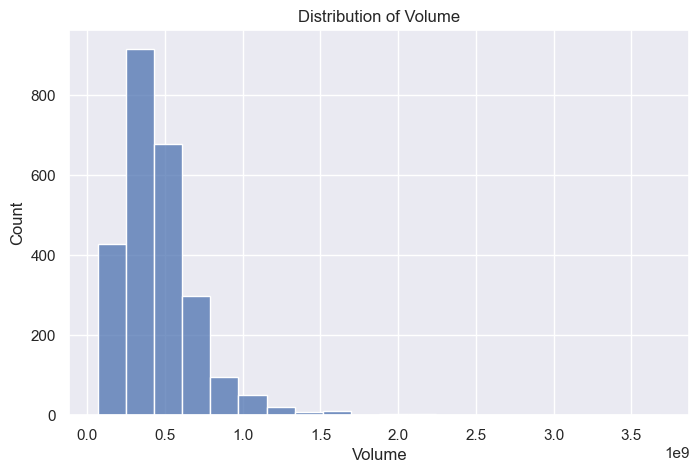

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Volume'], bins=20)
plt.title("Distribution of Volume")
plt.show()

- The histogram shows the distribution of daily trading Volume. Most days have low-to-moderate volume while a small number of days have very large spikes, producing a pronounced right (positive) skew and visible outliers.  
- These high-volume days likely correspond to major events (earnings, news, splits) and can disproportionately affect mean-based statistics. For modeling or visualization, consider a log-transform of Volume or using robust measures (median, IQR) to reduce the influence of extreme values.

## Bivariate Analysis

### Price and Volume Analysis

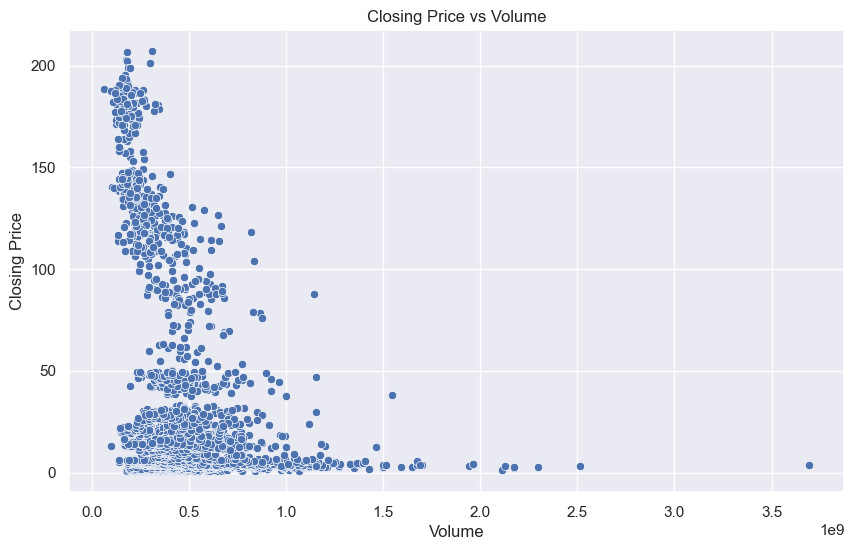

In [11]:
# Scatter plot: Closing Price vs Volume
plt.figure(figsize=(10,6))
sns.scatterplot(x='Volume', y='Close', data=df)
plt.title('Closing Price vs Volume')
plt.xlabel('Volume')
plt.ylabel('Closing Price')
plt.show()

### Daily Closing Price Over Time

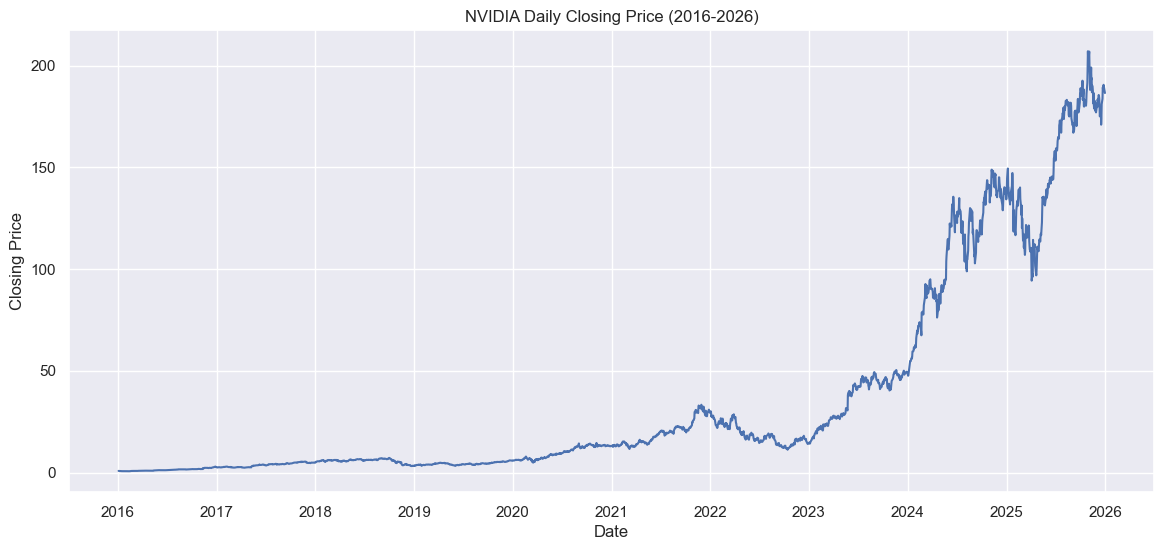

In [12]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'])
plt.title('NVIDIA Daily Closing Price (2016-2026)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

### Monthly Average Closing Price

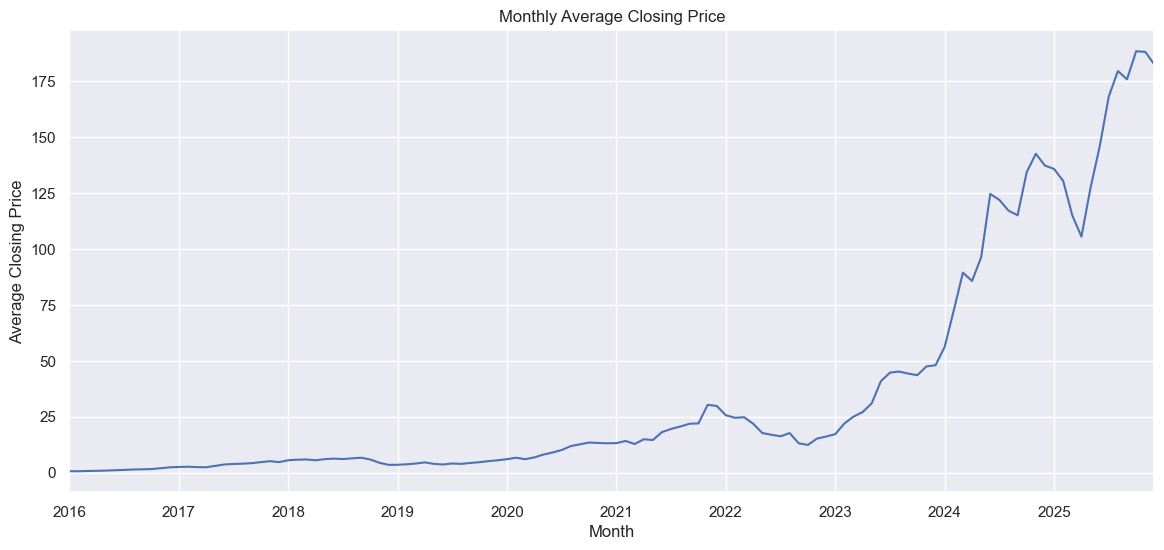

In [13]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_avg_close = df.groupby('Month')['Close'].mean()
plt.figure(figsize=(14,6))
monthly_avg_close.plot()
plt.title('Monthly Average Closing Price')
plt.xlabel('Month')
plt.ylabel('Average Closing Price')
plt.show()

### Correlation Matrix

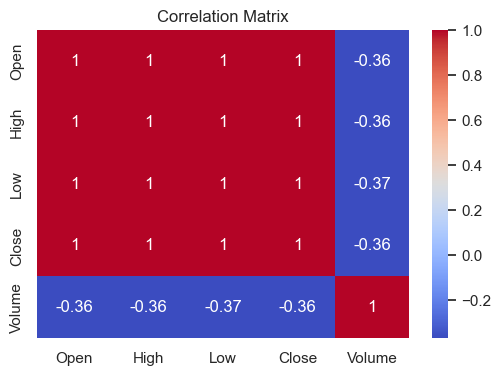

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Distribution of Daily Returns

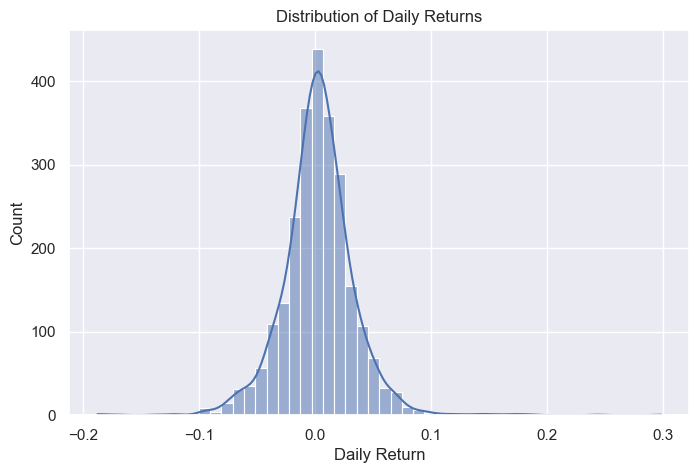

In [15]:
df['Daily Return'] = df['Close'].pct_change()
plt.figure(figsize=(8,5))
sns.histplot(df['Daily Return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Time-Based Analysis
### Monthly Revenue Trend

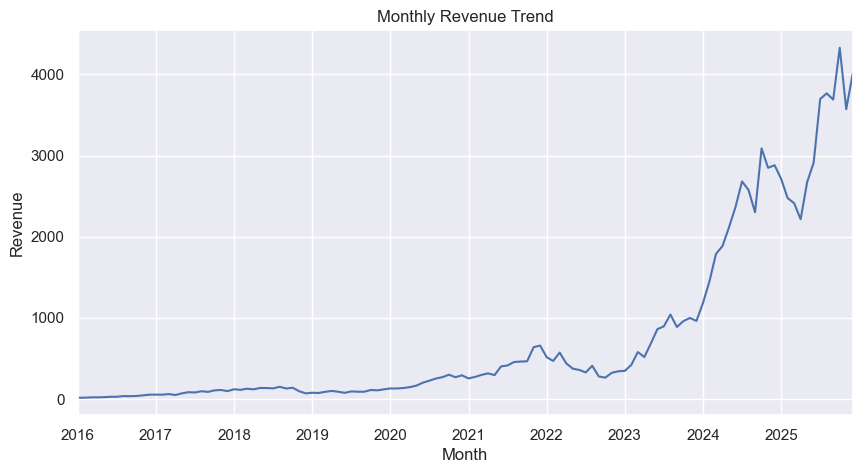

In [16]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Close'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.